In [15]:
import torch
import torch.nn as nn
import re
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from transformers import T5Tokenizer, T5EncoderModel

# loading data


In [16]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Základní encoder
tokenizer = T5Tokenizer.from_pretrained(
    'Rostlab/prot_t5_xl_half_uniref50-enc',
    do_lower_case=False
)

base_model = T5EncoderModel.from_pretrained(
    "Rostlab/prot_t5_xl_half_uniref50-enc"
)

if device.type == "cpu":
    base_model.to(torch.float32)


def nll_loss(mu, sigma, y):
    return torch.mean(0.5 * ((y - mu) ** 2) / (sigma ** 2) + torch.log(sigma))


class ProteinStabilityUncertaintyModel(nn.Module):
    def __init__(self, encoder, hidden_size=1024):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 2)  # predikujeme [mu, log_sigma]
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state.mean(dim=1)
        pred = self.head(pooled)
        mu = pred[:, 0]  # průměr predikovaného rozdělení
        log_sigma = pred[:, 1]
        sigma = F.softplus(log_sigma) + 1e-6  # zajistíme σ > 0
        return mu, sigma


class ProteinDataset(Dataset):
    def __init__(self, dataframe, tokenizer, target_col="normalized_fitness"):
        self.df = dataframe
        self.tokenizer = tokenizer
        self.target = dataframe[target_col].values

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        seq = self.df["aa_seq"].iloc[idx]
        # nahradíme neznámé AMK a vložíme mezery
        seq = " ".join(list(re.sub(r"[UZOB]", "X", seq)))
        enc = self.tokenizer(seq, padding="max_length", max_length=512, truncation=True, return_tensors="pt")
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["target"] = torch.tensor(self.target[idx], dtype=torch.float32)
        return item


df_train = pd.read_pickle("lehner_dataset.pkl")

train_dataset = ProteinDataset(df_train, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=12, shuffle=True)

# --- Model & optimizer ---
model = ProteinStabilityUncertaintyModel(base_model).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

ImportError: 
T5Tokenizer requires the SentencePiece library but it was not found in your environment. Check out the instructions on the
installation page of its repo: https://github.com/google/sentencepiece#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.


In [ ]:
from tqdm import tqdm

for epoch in range(5):
    model.train()
    total_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch + 1}")
    for batch in loop:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        targets = batch["target"].to(device)

        mu, sigma = model(input_ids, attention_mask)
        loss = nll_loss(mu, sigma, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item(), avg_loss=total_loss / len(loop))

    print(f"Epoch {epoch + 1} finished. Avg Loss: {total_loss / len(train_loader):.4f}")


Epoch 1:   0%|          | 0/50 [00:00<?, ?it/s]

In [11]:
import polars as pl

df = pl.read_csv("datasets/dataset_merged.csv")



ColumnNotFoundError: unable to find column "aa_seq"; valid columns: ["original_seq_full", "mutated_seq_full", "mut_type", "target", "reverse", "data_source"]

In [13]:
import polars as pl
from torch.utils.data import Dataset, DataLoader



class ProteinMutationDataset(Dataset):
    def __init__(self, processed_df: pl.DataFrame, tokenizer, max_length=1024):
        """
        Args:
            processed_df: Výstup z funkce prepare_data_with_polars
            tokenizer: HuggingFace tokenizer
        """
        self.tokenizer = tokenizer

        self.wt_seqs = processed_df["clean_wt"].to_list()
        self.mut_seqs = processed_df["clean_mut"].to_list()
        self.targets = processed_df["fitness"].to_list()

        self.max_length = max_length
        self.ids = list(range(len(self.targets)))

    def __len__(self):
        return len(self.targets)

    def add_spaces(self, seq):
        return " ".join(seq)

    def __getitem__(self, idx):
        # 1. Vytažení stringů (bleskové)
        seq_wt = self.add_spaces(self.wt_seqs[idx])
        seq_mut = self.add_spaces(self.mut_seqs[idx])
        target = self.targets[idx]
        row_id = self.ids[idx]

        # 2. Tokenizace
        # Zde už nepoužíváme truncation ani složité logiky, data jsou připravena.
        # Používáme padding=False pro Dynamic Padding v Collatoru.
        inputs = self.tokenizer(
            seq_wt,
            seq_mut,
            truncation=True,  # Pro jistotu, kdyby příprava selhala o pár znaků
            max_length=self.max_length,
            padding=False,  # DŮLEŽITÉ: Necháme padding na DataCollator
            return_token_type_ids=True
        )

        return {
            'input_ids': torch.tensor(inputs['input_ids'], dtype=torch.long),
            'attention_mask': torch.tensor(inputs['attention_mask'], dtype=torch.long),
            'token_type_ids': torch.tensor(inputs['token_type_ids'], dtype=torch.long),
            'labels': torch.tensor(target, dtype=torch.float),
            'row_idx': torch.tensor(row_id, dtype=torch.long)

        }


def prepare_data_dynamic(df: pl.DataFrame, max_total_length: int = 1024):
    """
    Přijme DF, parsuje sloupec 'mutation' pro získání pozice,
    ořízne sekvence a vrátí vyčištěná data.
    """

    half_window = (max_total_length - 3) // 2

    # Regulární výraz pro získání prvního čísla v řetězci
    # Příklady: "C622L" -> 622, "K18L:D65P" -> 18
    df_processed = df.with_columns([
        pl.col("mutation")
          .str.extract(r"(\d+)", 1) # Vytáhne první skupinu číslic
          .cast(pl.Int64)
          .alias("mutation_pos_1based"), # Pozice z biologie (od 1)

        pl.col("wt_sequence").str.len_chars().alias("seq_len")
    ])

    # Výpočet indexů a ořez
    df_processed = df_processed.with_columns([
        # Převod na 0-based index (Python) a výpočet startu
        # Pokud parsování selhalo (null), použijeme 0 (fallback)
        (pl.col("mutation_pos_1based").fill_null(1) - 1 - (half_window // 2))
          .clip(lower_bound=0)
          .alias("start_idx")
    ]).with_columns([
        # Korekce konce (aby ořez nepřetekl délku sekvence)
        pl.when((pl.col("start_idx") + half_window) > pl.col("seq_len"))
          .then((pl.col("seq_len") - half_window).clip(lower_bound=0))
          .otherwise(pl.col("start_idx"))
          .alias("final_start")
    ]).with_columns([
        # OŘEZ SEKVENCI
        pl.col("wt_sequence")
          .str.slice(pl.col("final_start"), half_window)
          .str.replace_all("[UZOB]", "X")
          .alias("clean_wt"),

        pl.col("mut_sequence")
          .str.slice(pl.col("final_start"), half_window)
          .str.replace_all("[UZOB]", "X")
          .alias("clean_mut")
    ])

    # --- FILTRACE CHYBNÝCH ---
    # Vyhodíme řádky, kde se ořez nepovedl (prázdné stringy)
    # nebo kde nešlo vyparsovat číslo mutace
    initial_len = len(df_processed)

    df_clean = df_processed.filter(
        (pl.col("clean_wt").str.len_chars() > 5) &
        (pl.col("mutation_pos_1based").is_not_null())
    )

    dropped = initial_len - len(df_clean)
    if dropped > 0:
        print(f"⚠️ VAROVÁNÍ: Vyhozeno {dropped} řádků (nepodařilo se určit pozici mutace nebo oříznout).")

    return df_clean


import torch
from transformers import BertTokenizer, DataCollatorWithPadding
from torch.utils.data import DataLoader
import polars as pl


# 1. NAČTENÍ KONFIGURACE A DAT
# Použijeme malý vzorek vašich dat
model_name = "Rostlab/prot_bert"
tokenizer = BertTokenizer.from_pretrained(model_name, do_lower_case=False)

# Načtěte kousek trénovacích dat (už po splitu, nebo raw)
df_sample = pl.read_csv("datasets/dataset_homology_split_test_noreverse.csv")

# 2. APLIKACE PREPROCESSINGU (Ověřená funkce)
print("Preprocessing sample...")
df_processed = prepare_data_dynamic(df_sample, max_total_length=1024)

print(df_processed.select([
    "wt_sequence",      # Původní
    "clean_wt",         # Oříznutá
    pl.col("clean_wt").str.len_chars().alias("len_wt"),
    "fitness"
]))

# 3. INICIALIZACE DATASETU A LOADERU
dataset = ProteinMutationDataset(df_processed, tokenizer, max_length=1024)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Důležité: Batch size > 1, abychom viděli, jestli funguje padding
loader = DataLoader(dataset, batch_size=4, collate_fn=data_collator, shuffle=False)

# 4. VYTAŽENÍ JEDNOHO BATCHE
print("\n--- TEST DATALOADERU ---")
try:
    batch = next(iter(loader))
except Exception as e:
    print(f"❌ CRITICAL ERROR: DataLoader spadl! \n{e}")
    exit()

# 5. KONTROLA STRUKTURY A ROZMĚRŮ
input_ids = batch['input_ids']
attention_mask = batch['attention_mask']
labels = batch['labels']
token_type_ids = batch['token_type_ids']

print(f"Batch keys: {batch.keys()}")
print(f"Input IDs shape: {input_ids.shape}")  # Mělo by být [4, délka_nejdelšího_v_batchi]
print(f"Labels shape:    {labels.shape}")
print(f"Labels dtype:    {labels.dtype}")  # Musí být torch.float32

# Kontrola Targetů (nesmí být NaN)
if torch.isnan(labels).any():
    print("🚨 VAROVÁNÍ: Labels obsahují NaN!")

# 6. ZPĚTNÝ PŘEKLAD (DEKÓDOVÁNÍ) - TOHLE JE NEJDŮLEŽITĚJŠÍ
print("\n--- VISUÁLNÍ KONTROLA PRVNÍHO VZORKU ---")

# Vezmeme první protein z batche
ids = input_ids[0]
types = token_type_ids[0]

# Převedeme ID zpět na text (aminokyseliny)
decoded_text = tokenizer.decode(ids)

print(f"RAW DECODED:\n{decoded_text}")

# 7. ANALÝZA TOKENŮ
# Zkontrolujeme, jestli tam nejsou [UNK] (neznámé znaky)
if "[UNK]" in decoded_text:
    print("\n🚨 KRITICKÁ CHYBA: Tokenizer vygeneroval [UNK]!")
    print("   Příčina: Pravděpodobně chybí mezery mezi aminokyselinami.")
    print("   Řešení: Zkontrolujte metodu `add_spaces` v Datasetu.")
else:
    print("\n✅ Tokenizace vypadá OK (žádné [UNK]).")

# 8. KONTROLA SEPARACE (WT vs MUT)
# Měli bychom vidět strukturu: [CLS] A A A ... [SEP] B B B ... [SEP] [PAD]...
sep_count = (ids == tokenizer.sep_token_id).sum().item()
cls_count = (ids == tokenizer.cls_token_id).sum().item()

print(f"\nPočet [CLS] tokenů: {cls_count} (měl by být 1)")
print(f"Počet [SEP] tokenů: {sep_count} (měl by být 2)")

if sep_count != 2:
    print("🚨 CHYBA: Chybí oddělovač [SEP]! Model nepozná, kde končí WT a začíná MUT.")

# 9. KONTROLA TOKEN_TYPE_IDS
# Měly by tam být nuly (pro WT) a jedničky (pro MUT)
zeros = (types == 0).sum().item()
ones = (types == 1).sum().item()
print(f"Token Type IDs - Nuly: {zeros}, Jedničky: {ones}")

if ones == 0:
    print("🚨 CHYBA: Token Type IDs jsou samé nuly! Model nerozliší WT od MUT.")
else:
    print("✅ Token Type IDs vypadají správně (mix 0 a 1).")

print("\n--- TEST KOMPLETNÍ ---")

Preprocessing sample...
⚠️ VAROVÁNÍ: Vyhozeno 13715 řádků (nepodařilo se určit pozici mutace nebo oříznout).
shape: (5_715, 4)
┌─────────────────────────────────┬─────────────────────────────────┬────────┬───────────┐
│ wt_sequence                     ┆ clean_wt                        ┆ len_wt ┆ fitness   │
│ ---                             ┆ ---                             ┆ ---    ┆ ---       │
│ str                             ┆ str                             ┆ u32    ┆ f64       │
╞═════════════════════════════════╪═════════════════════════════════╪════════╪═══════════╡
│ MSALLQDPMIAGQVSKPLLSVRSEMNAELR… ┆ LQLQLQQQQQQQQQQPPPSTNQHPQPAPQA… ┆ 510    ┆ -0.309176 │
│ MTTKRSLFVRLVPCRCLRGEEETVTTLDYS… ┆ SAVDGKNIVRSKSATLLYDQPLQVFTGSSS… ┆ 510    ┆ -0.379962 │
│ MDCLCIVTTKKYRYQDEDTPPLEHSPAHLP… ┆ ERGNSGLGFSIAGGTDNPHIGDDPSIFITK… ┆ 510    ┆ -0.339377 │
│ MGEGGLPPAFQLLLRACDQGDTETARRLLE… ┆ TALMQATYHGNKEIVKYLLNQGADVTLRAK… ┆ 510    ┆ -0.391741 │
│ MAANMYRVGDYVYFENSSSNPYLIRRIEEL… ┆ RRRDISNTLIMLADKHAK

In [1]:
import polars as pl

df = pl.read_csv("datasets/dataset_homology_split_test.csv")

df

wt_sequence,mut_sequence,mutation,fitness,cath_class,cath_arch,cath_topology,cath_homology,data_source,reverse
str,str,str,f64,str,i64,i64,i64,str,bool
"""MTTKRSLFVRLVPCRCLRGEEETVTTLDYS…","""MTTKRSLFVRLVPCRCLRGEEETVTTLDYS…","""N1338G""",-0.245937,"""G3DSA:3""",30,730,30,"""lehner""",false
"""MVQQTNNAENTEALLAGESSDSGAGLELGI…","""MVQQTNNAENTEALLAGESSDSGAGLELGI…","""*82P""",-0.471317,"""G3DSA:3""",30,1370,10,"""lehner""",false
"""GQTVVIGDTTYHLNNPEAAQQIAKELAKKY…","""GQTVVIGDTTYHLNNPEAAQQIADELAKKY…","""K23D""",-0.016573,"""G3DSA:1""",10,260,40,"""megascale""",false
"""SAGGSAGGSAGGSAGGMISNAKIARINELA…","""SAGGSAGGSAGGSAGGMISNAKIARINELA…","""K16W:E26W""",0.263449,"""G3DSA:1""",20,58,90,"""megascale""",true
"""MGKITFYEDRAFQGRSYETTTDCPNLQPYF…","""MGKITFYEDRAFQGRSYETTTDCPNLQPYF…","""E76I""",-0.277585,"""G3DSA:1""",10,10,10,"""lehner""",false
…,…,…,…,…,…,…,…,…,…
"""SAGGPVYLSVKADNSMFIGNDPVTDETMIT…","""SAGGPVYLSVKADNSMFIGNDPVTDETMIT…","""T32N:A63D""",0.401183,"""G3DSA:1""",10,10,10,"""megascale""",true
"""MRPGTGAERGGLMVSEMESHPPSQGPGDGE…","""MRPGTGAERGGLMVSEMESHPPSQGPGDGE…","""M698D""",-0.278363,"""G3DSA:1""",10,260,40,"""lehner""",false
"""MDSSCHNATTKMLATAPARGNMMSTSKPLA…","""MDSSCHNATTKMLATAPARGNMMSTSKPLA…","""S307K""",0.135224,"""G3DSA:1""",10,260,40,"""lehner""",false


In [3]:
import polars as pl

# 1. Funkce pro nalezení fyzického rozdílu
def find_real_diff_idx(struct):
    s1, s2 = struct['wt'], struct['mut']
    # Najdeme první znak, kde se liší
    limit = min(len(s1), len(s2))
    for i in range(limit):
        if s1[i] != s2[i]:
            return i
    return -1 # Nedohledáno (identické)

# 2. Načtení dat (Předpokládám raw data)
# df = pl.read_csv("vase_data.csv") ...
# Pro demo použiju df z paměti, pokud ho máte

print(f"Diagnostika datasetu ({len(df)} řádků)...")

# 3. Analýza Offsetu
df_diag = df.with_columns([
    # A) Fyzický index (0-based)
    pl.struct([pl.col("wt_sequence").alias("wt"), pl.col("mut_sequence").alias("mut")])
      .map_elements(find_real_diff_idx, return_dtype=pl.Int64)
      .alias("real_idx"),

    # B) Index z názvu (1-based -> převedeme na 0-based teoretický)
    pl.col("mutation") # nebo "mutation"
      .str.extract(r"(\d+)", 1)
      .cast(pl.Int64)
      .fill_null(0) # fallback
      .sub(1)       # 1-based na 0-based
      .alias("expected_idx_0based")
])

# 4. Výpočet Offsetu (Realita - Očekávání)
df_diag = df_diag.with_columns([
    (pl.col("real_idx") - pl.col("expected_idx_0based")).alias("offset")
])

# 5. Výpis statistik
valid_diffs = df_diag.filter(pl.col("real_idx") != -1)
print(f"Počet validních párů (WT!=MUT): {len(valid_diffs)} z {len(df)}")

print("\n--- STATISTIKA OFFSETŮ ---")
print("Kolik znaků přbývá/chybí na začátku sekvence oproti číslování?")
print(valid_diffs["offset"].value_counts().sort("count", descending=True).head(10))

# 6. Ukázka chyb
print("\n--- UKÁZKA ROZDÍLŮ ---")
valid_diffs.filter(pl.col("real_idx") != pl.col("expected_idx_0based"))

Diagnostika datasetu (188632 řádků)...
Počet validních párů (WT!=MUT): 188632 z 188632

--- STATISTIKA OFFSETŮ ---
Kolik znaků přbývá/chybí na začátku sekvence oproti číslování?
shape: (10, 2)
┌────────┬────────┐
│ offset ┆ count  │
│ ---    ┆ ---    │
│ i64    ┆ u32    │
╞════════╪════════╡
│ 0      ┆ 115206 │
│ 12     ┆ 12384  │
│ 4      ┆ 9748   │
│ 8      ┆ 7967   │
│ 5      ┆ 7412   │
│ 1      ┆ 6692   │
│ 2      ┆ 5686   │
│ 9      ┆ 5469   │
│ 7      ┆ 3368   │
│ 11     ┆ 3320   │
└────────┴────────┘

--- UKÁZKA ROZDÍLŮ ---


wt_sequence,mut_sequence,mutation,fitness,cath_class,cath_arch,cath_topology,cath_homology,data_source,reverse,real_idx,expected_idx_0based,offset
str,str,str,f64,str,i64,i64,i64,str,bool,i64,i64,i64
"""GQTVVIGDTTYHLNNPEAAQQIAKELAKKY…","""GQTVVIGDTTYHLNNPEAAQQIAKELAKKY…","""L31N""",-0.128695,"""G3DSA:1""",10,260,40,"""megascale""",false,31,30,1
"""SAGGSAGGSAGGSAGGMISNAKIARINELA…","""SAGGSAGGSAGGSAGGMISNAKIARINELA…","""K16W:E26W""",0.263449,"""G3DSA:1""",20,58,90,"""megascale""",true,31,15,16
"""SAGGSAVSDRLIGRKGVVMEAISPQNSALV…","""SAGGSAVSDRLIGRKGVVMEAISPQNSALV…","""E44Y""",0.133437,"""G3DSA:6""",10,250,3180,"""megascale""",true,48,43,5
"""SAGGSHSHMSHTQVIELERKFSHQKYLSAP…","""SAGGSHSHMSHTQVIELERKFSHKKYLSAP…","""Q19K:E26T""",-0.13686,"""G3DSA:3""",40,50,10810,"""megascale""",false,23,18,5
"""GQTVVIGDTTYHLNNPEAAQQIAKELAKKY…","""GQTVVIGDTTYHLNNPEAAQQIAKHLAKKY…","""E24H""",0.043996,"""G3DSA:1""",10,260,40,"""megascale""",false,24,23,1
…,…,…,…,…,…,…,…,…,…,…,…,…
"""SAGGSAGGSAGGTEVDLHLGDITIKLKDVS…","""SAGGSAGGSAGGTEVDLHLGDITIKLKDVS…","""W41D""",0.429643,"""G3DSA:1""",10,8,550,"""megascale""",true,52,40,12
"""SATNIVSKVKWYNSTKNFTFIEQDNGGKDV…","""SATNIVSKVKWYNSTKNFGFIEQDNGGKDV…","""G18T""",0.379334,"""G3DSA:1""",10,533,10,"""megascale""",true,18,17,1
"""SAGGSAGTGIVNVSSSLNVRSSASTSSKVI…","""SAGGSAGTGIVNVSSSLNVRSSASTSSKVI…","""G51W""",0.262326,"""G3DSA:3""",30,1370,10,"""megascale""",true,57,50,7


In [2]:
import torch
from transformers import BertTokenizer
import polars as pl

# 1. Načti model a data
tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)
# Předpokládám, že máš někde už zpracovaný dataframe 'df' (nebo ho načti)
# df = pl.read_csv(...)

# Vezmeme jeden řádek, kde VÍME, že je mutace
row = df.head(1)
wt_seq = row["clean_wt"][0]   # Už oříznuté sekvence
mut_seq = row["clean_mut"][0]
fitness = row["fitness"][0]

print(f"Target Fitness: {fitness}")

# 2. Tokenizace (přesně jako v Datasetu)
# Simulujeme __getitem__
def add_spaces(s): return " ".join(s)

inputs = tokenizer(
    add_spaces(wt_seq),
    add_spaces(mut_seq),
    truncation=True,
    max_length=1024,
    return_token_type_ids=True,
    return_tensors="pt" # Vrací tenzory
)

# 3. Zpětný překlad (Co vidí model?)
input_ids = inputs["input_ids"][0]
token_type_ids = inputs["token_type_ids"][0]

decoded = tokenizer.convert_ids_to_tokens(input_ids)

print("\n--- CO VIDÍ MODEL (Tokeny) ---")
print(decoded)

print("\n--- ANALÝZA ---")
# A) Jsou tam [SEP]?
sep_indices = (input_ids == tokenizer.sep_token_id).nonzero(as_tuple=True)[0]
print(f"Počet [SEP] tokenů: {len(sep_indices)} (Musí být 2!)")

# B) Jsou tam [UNK]?
unk_count = decoded.count("[UNK]")
print(f"Počet [UNK] tokenů: {unk_count} (Musí být 0!)")

# C) Rozlišuje model WT a MUT? (Token Type IDs)
print(f"Token Types (0=WT, 1=MUT): {token_type_ids.tolist()}")
if token_type_ids.sum() == 0:
    print("❌ CHYBA: Všechno je označené jako WT (0). Model nepozná druhou sekvenci!")
else:
    print("✅ OK: Model vidí segment A a segment B.")

# D) Je tam fyzický rozdíl?
# Najdeme indexy, kde se sekvence liší
# Musíme ignorovat speciální tokeny
wt_part_ids = input_ids[token_type_ids == 0]
mut_part_ids = input_ids[token_type_ids == 1]

# Pozor: WT part obsahuje [CLS] a [SEP], MUT part obsahuje [SEP]
# Ořízneme speciální tokeny pro porovnání
wt_pure = wt_part_ids[1:-1] # Bez CLS a SEP
mut_pure = mut_part_ids[:-1] # Bez posledního SEP

if torch.equal(wt_pure, mut_pure):
    print("❌ KRITICKÁ CHYBA: WT a MUT tokeny jsou IDENTICKÉ! Model nevidí žádnou změnu.")
else:
    print("✅ OK: WT a MUT se liší.")
    # Vypíšeme kde
    diff_mask = wt_pure != mut_pure
    print(f"Rozdíl nalezen na indexech: {diff_mask.nonzero().flatten().tolist()}")

/home/jvlk/miniconda3/envs/protbert/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/361 [00:00<?, ?B/s]

ColumnNotFoundError: "clean_wt" not found

In [1]:
import polars as pl

df = pl.read_csv("datasets/dataset_homology_split_test.csv")
df2 = pl.read_csv("datasets/dataset_homology_split_train.csv")
df3 = pl.read_csv("datasets/dataset_homology_split_validation.csv")

df_full = pl.concat([df, df2, df3])

df_full

wt_sequence,mut_sequence,mutation,fitness,cath_class,cath_arch,cath_topology,cath_homology,data_source,reverse
str,str,str,f64,str,i64,i64,i64,str,bool
"""MTTKRSLFVRLVPCRCLRGEEETVTTLDYS…","""MTTKRSLFVRLVPCRCLRGEEETVTTLDYS…","""C1372G""",-0.286319,"""G3DSA:3""",30,730,30,"""lehner""",false
"""MVQQTNNAENTEALLAGESSDSGAGLELGI…","""MVQQTNNAENTEALLAGESSDSGAGLELGI…","""V124P""",-0.042066,"""G3DSA:3""",30,1370,10,"""lehner""",false
"""GQTVVIGDTTYHLNNPEAAQQIAKELAKKY…","""GQTVVIGDTTYHLNNPEAAQQIAKELAKKY…","""V35K""",-0.094397,"""G3DSA:1""",10,260,40,"""megascale""",false
"""SAGGSAGGSAGGSAGGMISNAKIARINELA…","""SAGGSAGGSAGGSAGGMISNAKIARINELA…","""K32W:E42W""",0.233383,"""G3DSA:1""",20,58,90,"""megascale""",true
"""MGKITFYEDRAFQGRSYETTTDCPNLQPYF…","""MGKITFYEDRAFQGRSYETTTDCPNLQPYF…","""Y68Q""",0.012739,"""G3DSA:1""",10,10,10,"""lehner""",false
…,…,…,…,…,…,…,…,…,…
"""SAGGTYTWNTKEEAKQAFKELLKEKRVPSN…","""SAGGTYTWNTKEEAKQAFKELLKEKRVPSN…","""L49S""",-0.258713,"""G3DSA:1""",20,58,60,"""megascale""",false
"""MGKKSRAVPGRRPILQLSPPGPRGSTPGRD…","""MGKKSRAVPGRRPILQLSPPGPRGSTPGRD…","""*209S""",-0.345165,"""G3DSA:3""",10,20,510,"""lehner""",false
"""SAGGSHSHMSHTQVIELERKFSHQKYLSAP…","""SAGGSHSHMSHTQVIELERKFSHQKYLSAP…","""N52P""",-0.168865,"""G3DSA:3""",40,50,10810,"""megascale""",false


In [11]:
df_full.filter(pl.col("reverse") == False).select(pl.col("fitness")).describe()

statistic,fitness
str,f64
"""count""",864033.0
"""null_count""",0.0
"""mean""",0.000785
"""std""",0.235631
"""min""",-0.980373
"""25%""",-0.122668
"""50%""",-0.009576
"""75%""",0.097114
"""max""",0.980353


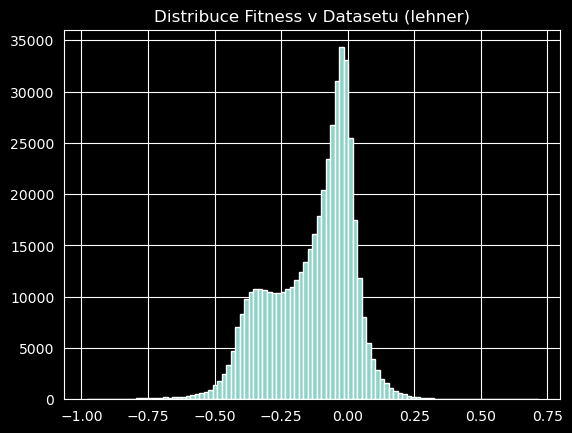

In [12]:
# histogram fitness
import matplotlib.pyplot as plt
plt.hist(df_full.filter(pl.col("reverse") == False).filter(pl.col("data_source") == "lehner").select(pl.col("fitness")).to_series(), bins=100)
plt.title("Distribuce Fitness v Datasetu (lehner)")
plt.show()

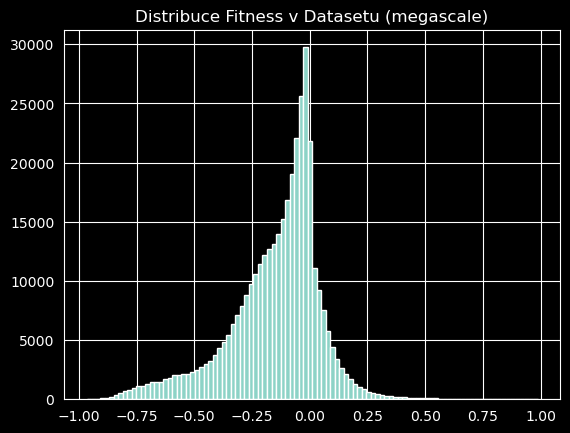

In [2]:
import matplotlib.pyplot as plt
plt.hist(df_full.filter(pl.col("reverse") == False).filter(pl.col("data_source") == "megascale").select(pl.col("fitness")).to_series(), bins=100)
plt.title("Distribuce Fitness v Datasetu (megascale)")
plt.show()